# Análisis Exploratorio de Datos (EDA) - US Accidents

Este notebook contiene el Análisis Exploratorio de Datos (EDA) para el dataset de accidentes de EE. UU. Se evalúa la estructura general, valores faltantes, duplicados y las principales distribuciones de las variables clave.

In [ ]:
import os
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd

# Descargar la última versión del dataset
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")

# Construir la ruta del archivo CSV
csv_path = os.path.join(path, "US_Accidents_March23.csv")

# Cargar una muestra de los datos para agilizar el análisis
df = pd.read_csv(csv_path, nrows=100000)

## 2. Información General del Dataset

Inspección de la forma del dataframe (`shape`) y el tipo de datos por columna (`info()`).

In [11]:
print("Dimensiones del dataset:", df.shape)
print("\nInformación general:")
print(df.info())

Dimensiones del dataset: (100000, 46)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     100000 non-null  object 
 1   Source                 100000 non-null  object 
 2   Severity               100000 non-null  int64  
 3   Start_Time             100000 non-null  object 
 4   End_Time               100000 non-null  object 
 5   Start_Lat              100000 non-null  float64
 6   Start_Lng              100000 non-null  float64
 7   End_Lat                0 non-null       float64
 8   End_Lng                0 non-null       float64
 9   Distance(mi)           100000 non-null  float64
 10  Description            100000 non-null  object 
 11  Street                 100000 non-null  object 
 12  City                   99999 non-null   object 
 13  County                 100000 

## 3. Análisis de Valores Faltantes

Identificación y visualización de las 20 variables que presentan la mayor cantidad de datos nulos.

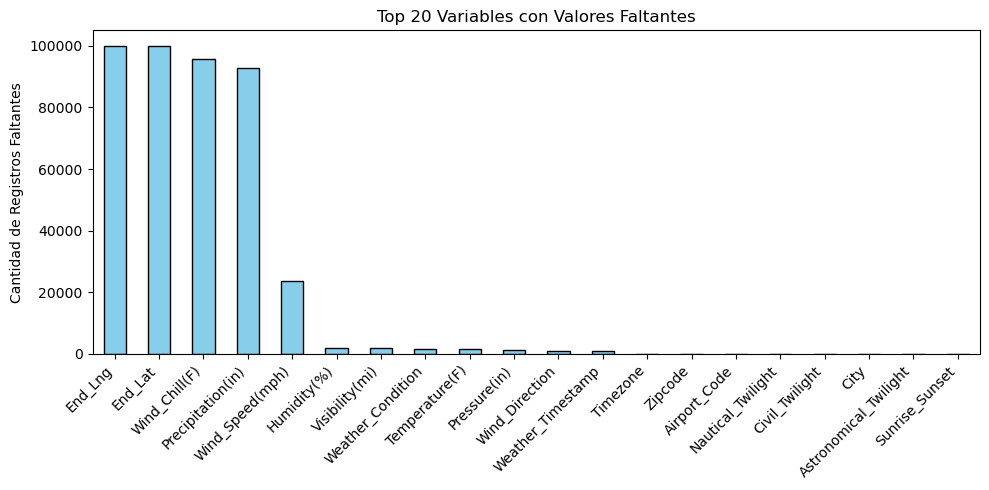

In [12]:
missing = df.isnull().sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 5))
missing.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Top 20 Variables con Valores Faltantes")
plt.ylabel("Cantidad de Registros Faltantes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. Análisis de Registros Duplicados

Verificación de la existencia de filas completamente idénticas dentro de la muestra cargada.

In [13]:
print("Cantidad de registros duplicados:", df.duplicated().sum())

Cantidad de registros duplicados: 0


## 5. Distribución de la Severidad de los Accidentes

Visualización del impacto o gravedad de los accidentes registrados en el dataset.

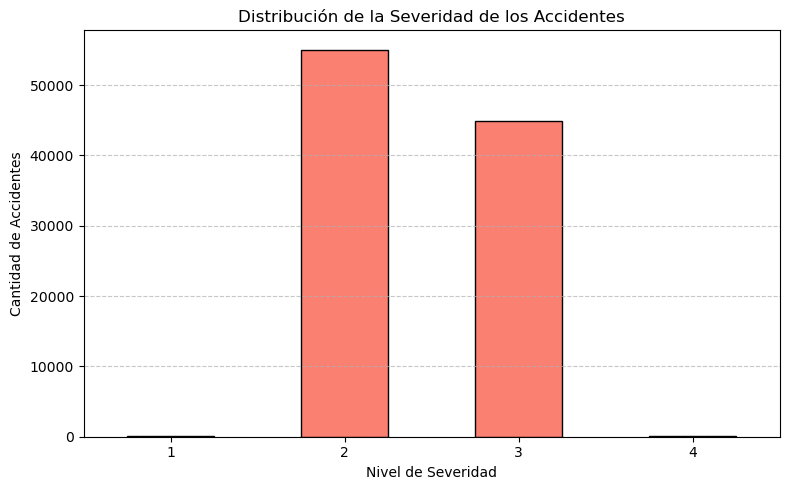

In [14]:
plt.figure(figsize=(8, 5))
df["Severity"].value_counts().sort_index().plot(kind="bar", color="salmon", edgecolor="black")
plt.title("Distribución de la Severidad de los Accidentes")
plt.xlabel("Nivel de Severidad")
plt.ylabel("Cantidad de Accidentes")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## 6. Distribución de Accidentes por Hora

Conversión de la columna `Start_Time` a formato datetime para extraer la hora del día en la que ocurren más siniestros.

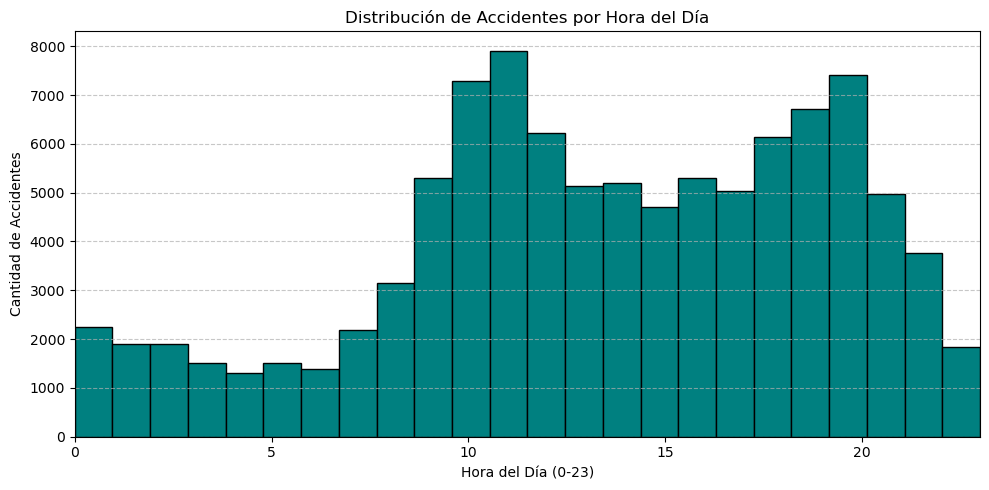

In [15]:
# Conversión controlando formatos mixtos
df["Start_Time"] = pd.to_datetime(df["Start_Time"], format="mixed", errors="coerce")
df["Hour"] = df["Start_Time"].dt.hour

plt.figure(figsize=(10, 5))
df["Hour"].hist(bins=24, color="teal", edgecolor="black", grid=False)
plt.title("Distribución de Accidentes por Hora del Día")
plt.xlabel("Hora del Día (0-23)")
plt.ylabel("Cantidad de Accidentes")
plt.xlim(0, 23)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## 7. Estados con Mayor Número de Accidentes

Gráfico de barras que muestra los 10 estados con mayor concentración de reportes en la muestra.

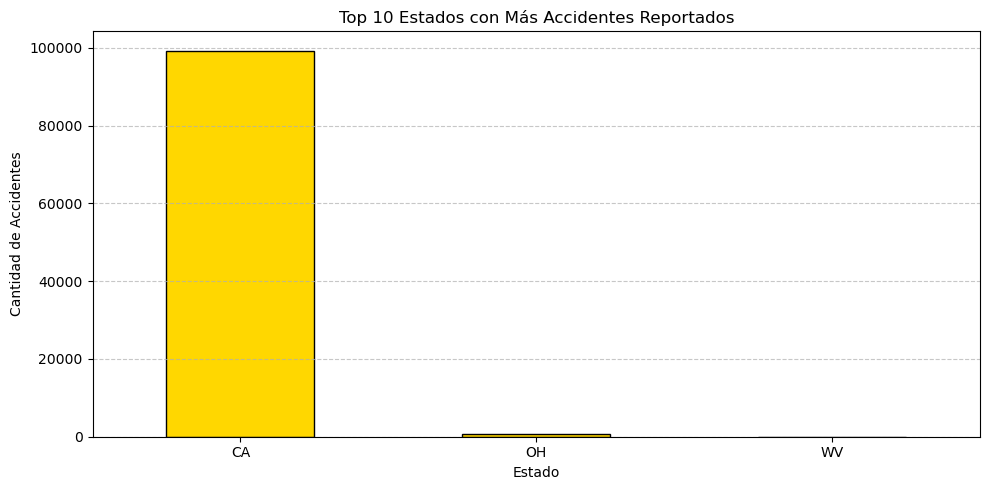

In [16]:
plt.figure(figsize=(10, 5))
df["State"].value_counts().head(10).plot(kind="bar", color="gold", edgecolor="black")
plt.title("Top 10 Estados con Más Accidentes Reportados")
plt.xlabel("Estado")
plt.ylabel("Cantidad de Accidentes")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## 8. Condiciones Climáticas Más Frecuentes

Análisis de los escenarios climáticos predominantes en el momento en que se registraron los accidentes.

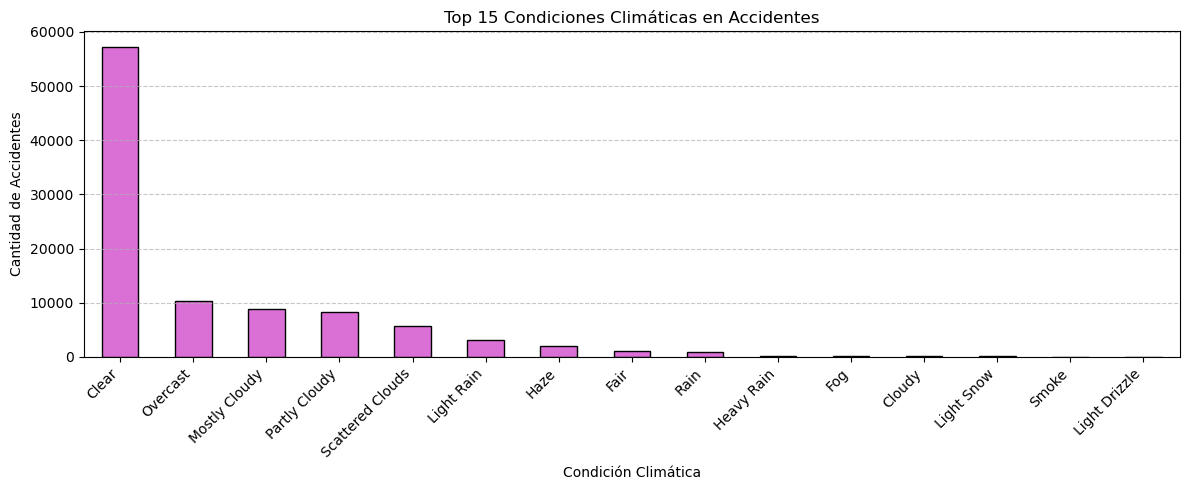

In [17]:
plt.figure(figsize=(12, 5))
df["Weather_Condition"].value_counts().head(15).plot(kind="bar", color="orchid", edgecolor="black")
plt.title("Top 15 Condiciones Climáticas en Accidentes")
plt.xlabel("Condición Climática")
plt.ylabel("Cantidad de Accidentes")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## 9. Distribución de la Temperatura

Visualización del comportamiento de la temperatura ambiental (en grados Fahrenheit) registrada en los puntos de los accidentes.

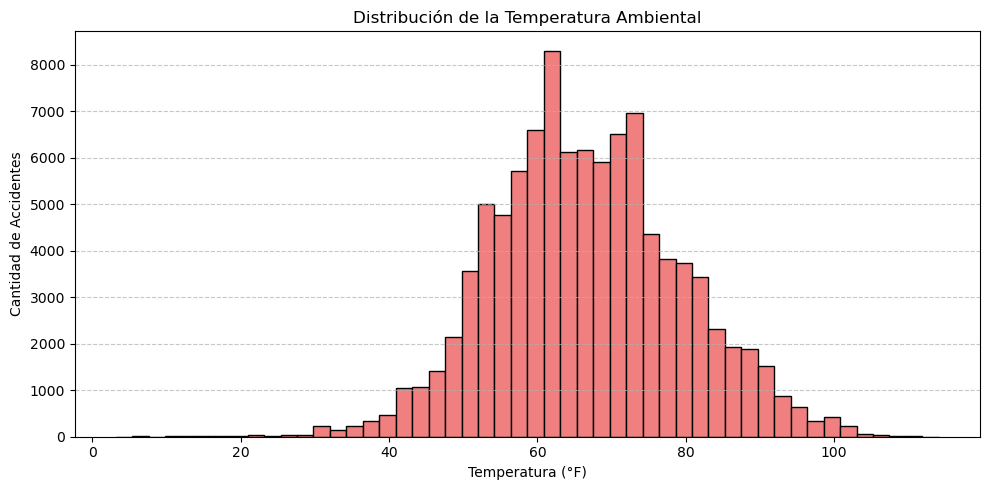

In [18]:
plt.figure(figsize=(10, 5))
df["Temperature(F)"].hist(bins=50, color="lightcoral", edgecolor="black", grid=False)
plt.title("Distribución de la Temperatura Ambiental")
plt.xlabel("Temperatura (°F)")
plt.ylabel("Cantidad de Accidentes")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()